In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

# Set seed 
np.random.seed(42)

In [2]:
#sns.set_theme(style="whitegrid")
#sns.set_context("paper", font_scale=1.2)
#sns.set_palette("Spectral", n_colors=12)

In [3]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="talk",   # important: larger defaults than "notebook"
    rc={
        # Grid: very light, behind data
        "grid.color": "#E5E5E5",
        "grid.linewidth": 0.8,
        "grid.alpha": 1.0,
        "axes.axisbelow": True,

        # Background
        "axes.facecolor": "white",
        "figure.facecolor": "white",

        # Axes (Prism-like)
        "axes.linewidth": 1.8,
        "axes.edgecolor": "black",
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Fonts (slide readable)
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 16,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 14,

        # Ticks: explicitly outside
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 1.8,
        "ytick.major.width": 1.8,
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        "xtick.minor.size": 4,
        "ytick.minor.size": 4,
        "xtick.color": "black",
        "ytick.color": "black",

        # Lines & error bars
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "errorbar.capsize": 5,
    }
)


# Handling the data

In [4]:
# Load the data
df = pd.read_csv("data/proportionsPKH26-EVIR.csv", sep = ';', decimal = ',')

In [5]:
df_means_std = pd.read_csv("data/proportionsPKH26_EVIR_mean_std.csv", sep = ";", decimal=",").iloc[:18]
df_means_std.drop("Unnamed: 0", axis=1, inplace=True)
df_means_std = df_means_std.fillna(0)


In [6]:
# Delete lines for the US samples
df_means_std = df_means_std[df_means_std["Name"] != "US"]

# Figures

### Proportions of EVIR and PKH26 over all cells

In [7]:
# Mean
two_hours_df_mean = (
    df.groupby("Time point")[["EVIR+", "EVIR-", "PKH26+", "PKH26-"]]
      .mean()
      .reset_index()
)

# Standard deviation
two_hours_df_std = (
    df.groupby("Time point")[["EVIR+", "EVIR-", "PKH26+", "PKH26-"]]
      .std()
      .reset_index()
)

mean_long = two_hours_df_mean.melt(
    id_vars="Time point",
    var_name="Readout",
    value_name="Mean"
)

std_long = two_hours_df_std.melt(
    id_vars="Time point",
    var_name="Readout",
    value_name="SD"
)

# Merge mean + SD
plot_df = mean_long.merge(
    std_long,
    on=["Time point", "Readout"]
)


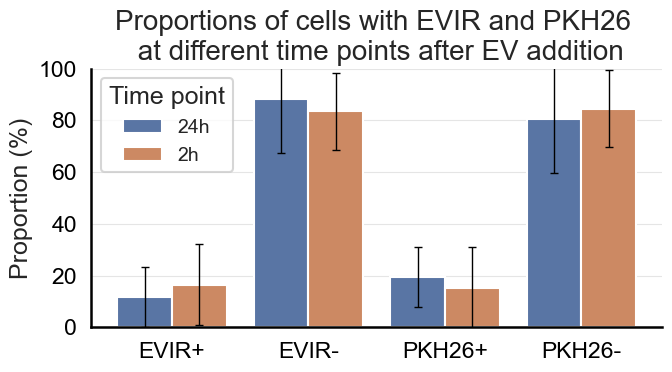

In [8]:
plt.figure(figsize=(7,4))
ax = sns.barplot(
    data=plot_df,
    x="Readout",
    y="Mean",
    hue="Time point",
)

# Add SD error bars manually
plot_df_sorted = plot_df.sort_values(["Readout", "Time point"]).reset_index(drop=True)

for patch, (_, row) in zip(ax.patches, plot_df_sorted.iterrows()):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    ax.errorbar(
        x, y,
        yerr=row["SD"],
        fmt="none",
        capsize=3,
        linewidth=1,
        color="black"
    )

ax.set_ylim(0, 100)
ax.set_ylabel("Proportion (%)")
ax.set_xlabel("")
ax.set_title("Proportions of cells with EVIR and PKH26 \n at different time points after EV addition")
plt.tight_layout();

## Proportions of PKH26+ cells

In [9]:
palette = sns.color_palette("Spectral", 12)


In [10]:
df_means_std.head()

,Time point,Name,Transfected,EVs,Frozen,EVIR+,EVIR+ (std),EVIR-,EVIR- (std),PKH26+,PKH26+ (std),PKH26-,PKH26- (std)
1,2h,EVIR GD2+,1.0,1.0,0.0,25.066667,5.601190,74.933333,5.601190,2.590,1.976841,97.40,1.969772
2,2h,EVIR GD2-,1.0,0.0,0.0,27.950000,1.344000,72.050000,1.344000,0.930,0.297000,99.10,0.283000
3,2h,UT GD2+,0.0,1.0,0.0,1.402000,0.373323,98.620000,0.363318,34.180,9.102033,65.82,9.102033
4,2h,UT GD2-,0.0,0.0,0.0,1.350000,0.000000,98.700000,0.000000,9.630,0.000000,90.40,0.000000
5,2h,EVIR GD2+,1.0,1.0,1.0,56.500000,3.394113,43.500000,3.394113,7.295,0.869741,92.70,0.848528


In [11]:
def plot_panel(data, axis, title, marker):
    sns.barplot(
        data=data,
        x="Name",
        y=marker,
        hue="Frozen",
        errorbar=None,
        palette=("#FF6F61", "#0887A0"),
        saturation=1,
        ax=axis
    )

    # Add error bars manually
    for container, frozen_val in zip(axis.containers, sorted(data["Frozen"].unique())):
        subset = data[data["Frozen"] == frozen_val].reset_index(drop=True)
        for bar, (_, row) in zip(container, subset.iterrows()):
            x = bar.get_x() + bar.get_width() / 2
            axis.errorbar(
                x,
                row[marker],
                yerr=row[marker + " (std)"],
                fmt="none",
                ecolor="black",
                capsize=4,
                linewidth=1
            )

    axis.set_title(title + " after EVs addition")
    axis.set_xlabel("")
    axis.set_ylabel(marker + " (%)")
    axis.set_ylim(0, 100)
    axis.tick_params(axis="x", rotation=45)

    axis.legend(title="Frozen", labels=["No", "Yes"])

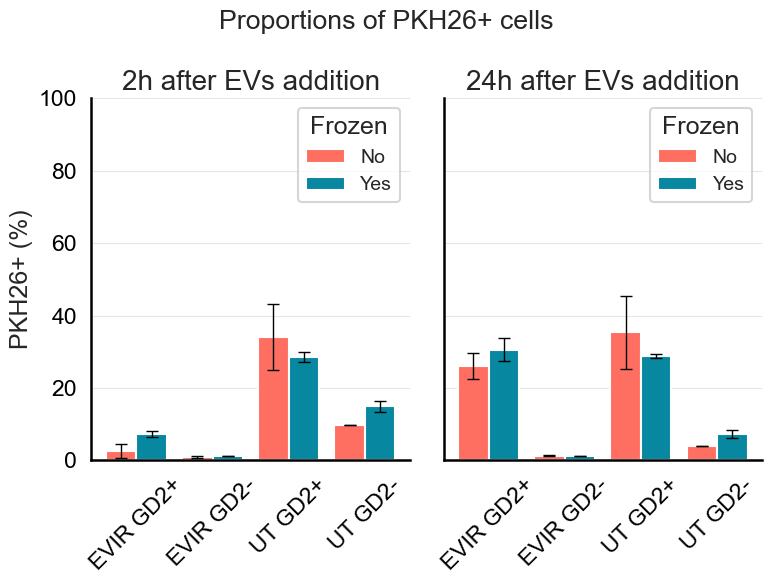

In [12]:

# Split by time point
df_2h  = df_means_std[df_means_std["Time point"] == "2h"]
df_24h = df_means_std[df_means_std["Time point"] == "24h"]

fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# 1) Compute t-tests from RAW data (not df_means_std)

plot_panel(df_2h,  ax[0], "2h", "PKH26+")
plot_panel(df_24h, ax[1], "24h", "PKH26+")

plt.suptitle("Proportions of PKH26+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionPKH26");

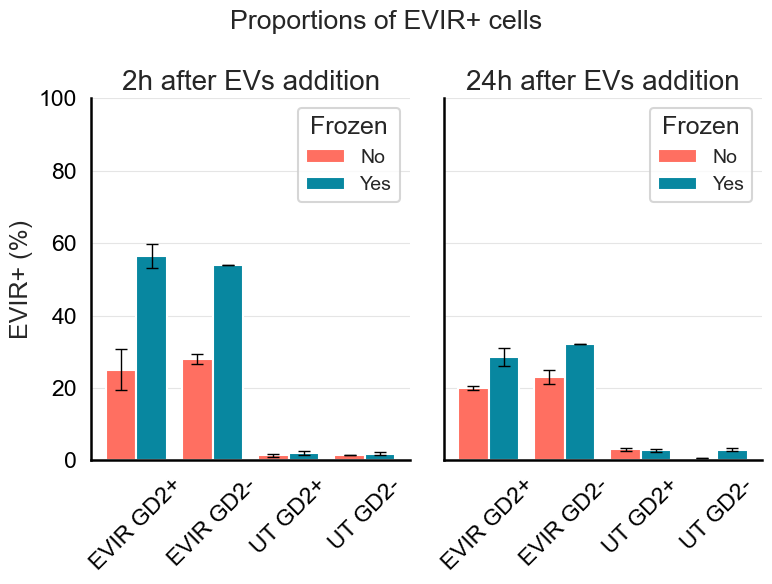

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

plot_panel(df_2h,  ax[0], "2h", "EVIR+")
plot_panel(df_24h, ax[1], "24h", "EVIR+")

plt.suptitle("Proportions of EVIR+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionEVIR");

## Statistical significance

In [14]:
# Compute t-tests (Frozen 0 vs 1) for EVIR+ and PKH26+
import pandas as pd
from scipy.stats import ttest_ind

markers = ["EVIR+", "PKH26+"]
results = []
for tp in df["Time point"].unique():
    sub_tp = df[df["Time point"] == tp]
    for name in sub_tp["Name"].unique():
        sub_name = sub_tp[sub_tp["Name"] == name]
        for marker in markers:
            g0 = pd.to_numeric(sub_name[sub_name["Frozen"] == 0][marker], errors='coerce').dropna()
            g1 = pd.to_numeric(sub_name[sub_name["Frozen"] == 1][marker], errors='coerce').dropna()
            p = None
            stat = None
            if len(g0) > 0 and len(g1) > 0:
                stat, p = ttest_ind(g0, g1, equal_var=False)
            results.append({
                "Time point": tp,
                "Name": name,
                "Marker": marker,
                "n_no_frozen": len(g0),
                "n_frozen": len(g1),
                "t_stat": stat,
                "p_value": p,
            })

ttest_table = pd.DataFrame(results)

def p_to_stars(p):
    if p is None or pd.isna(p):
        return "na"
    if p < 0.0001:
        return '****'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

if not ttest_table.empty:
    ttest_table['stars'] = ttest_table['p_value'].apply(p_to_stars)
    display(ttest_table.sort_values(['Time point','Marker','Name']).reset_index(drop=True))
    ttest_table.to_csv('Figures/assessing_function/ttest_table.csv', index=False)
else:
    print('No comparisons were performed (no data).')

,Time point,Name,Marker,n_no_frozen,n_frozen,t_stat,p_value,stars
0,24h,EVIR GD2+,EVIR+,3,2,-4.072064,0.113897,ns
1,24h,EVIR GD2-,EVIR+,2,1,NaN,NaN,na
2,24h,US,EVIR+,1,0,NaN,NaN,na
3,24h,UT GD2+,EVIR+,5,2,0.866832,0.499314,ns
4,24h,UT GD2-,EVIR+,1,2,NaN,NaN,na
5,24h,EVIR GD2+,PKH26+,3,2,-1.475021,0.263662,ns
6,24h,EVIR GD2-,PKH26+,2,1,NaN,NaN,na
7,24h,US,PKH26+,1,0,NaN,NaN,na
8,24h,UT GD2+,PKH26+,5,2,1.449025,0.219599,ns
9,24h,UT GD2-,PKH26+,1,2,NaN,NaN,na


In [15]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def plot_panel_pvalue(data, axis, title, marker):
    sns.barplot(
        data=data,
        x="Name",
        y=marker,
        hue="Frozen",
        errorbar=None,
        palette=("#FF6F61", "#0887A0"),
        saturation=1,
        ax=axis
    )

    # Add error bars
    for container, frozen_val in zip(axis.containers, sorted(data["Frozen"].unique())):
        subset = data[data["Frozen"] == frozen_val].reset_index(drop=True)
        for bar, (_, row) in zip(container, subset.iterrows()):
            x = bar.get_x() + bar.get_width() / 2
            axis.errorbar(
                x,
                row[marker],
                yerr=row.get(marker + " (std)", 0),
                fmt="none",
                ecolor="black",
                capsize=4,
                linewidth=1
            )

    axis.set_title(title + " after EVs addition")
    axis.set_xlabel("")
    axis.set_ylabel(marker + " (%)")
    axis.set_ylim(0, 100)
    axis.tick_params(axis="x", rotation=45)

    # Compute and annotate p-values (Frozen 0 vs 1)
    names = list(data["Name"].unique())
    try:
        bars_frozen0 = axis.containers[0]
        bars_frozen1 = axis.containers[1]
    except Exception:
        bars_frozen0 = []
        bars_frozen1 = []

    for i, name in enumerate(names):
        tp = data["Time point"].iloc[0]
        subset_raw = df[(df["Time point"] == tp) & (df["Name"] == name)]
        g0 = pd.to_numeric(subset_raw[subset_raw["Frozen"] == 0][marker], errors='coerce').dropna()
        g1 = pd.to_numeric(subset_raw[subset_raw["Frozen"] == 1][marker], errors='coerce').dropna()
        p = None
        if len(g0) > 0 and len(g1) > 0:
            try:
                stat, p = ttest_ind(g0, g1, equal_var=False)
            except Exception:
                p = None

        try:
            bar0 = bars_frozen0[i]
            bar1 = bars_frozen1[i]
            x0 = bar0.get_x() + bar0.get_width() / 2
            x1 = bar1.get_x() + bar1.get_width() / 2
            y0 = bar0.get_height()
            y1 = bar1.get_height()
            y = max(y0, y1) + 5

            # Draw line
            axis.plot([x0, x1], [y, y], color='black', linewidth=1.2)
            axis.plot([x0, x0], [y, y - 1.5], color='black', linewidth=1.2)
            axis.plot([x1, x1], [y, y - 1.5], color='black', linewidth=1.2)

            # GraphPad-style mapping requested: ** : p <0.05, *** : p <0.005
            if p is None or (isinstance(p, float) and np.isnan(p)):
                stars = 'ns'
            elif p < 0.005:
                stars = '***'
            elif p < 0.05:
                stars = '**'
            else:
                stars = 'ns'

            axis.text((x0 + x1) / 2, y + 1, stars, ha='center', va='bottom', fontsize=12)
        except Exception:
            pass

    # Primary legend for Frozen
    frozen_legend = axis.legend(title="Frozen", labels=["No", "Yes"], loc='upper left')
    axis.add_artist(frozen_legend)

    # Secondary legend explaining stars (GraphPad-style)
    legend_handles = [Patch(facecolor='none', edgecolor='none', label='** : p <0.05'),
                      Patch(facecolor='none', edgecolor='none', label='*** : p <0.005')]
    axis.legend(handles=legend_handles, loc='upper right', frameon=False)


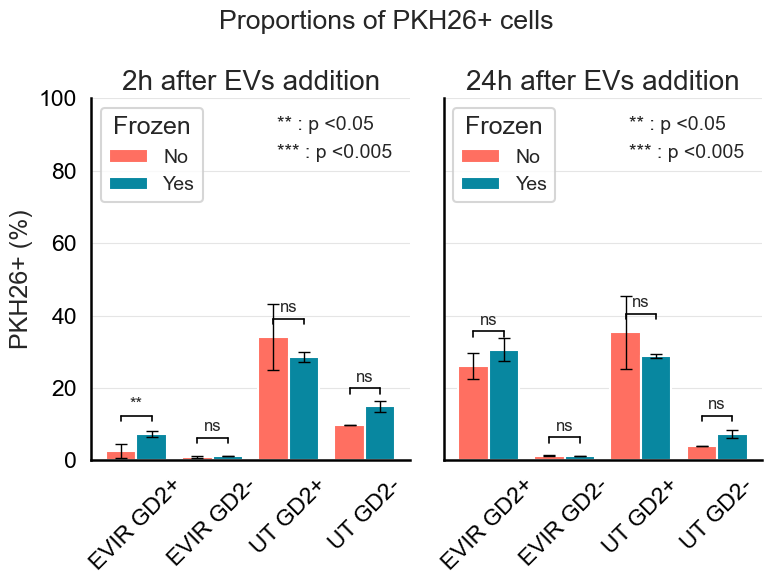

In [16]:

# Split by time point
df_2h  = df_means_std[df_means_std["Time point"] == "2h"]
df_24h = df_means_std[df_means_std["Time point"] == "24h"]

fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

# 1) Compute t-tests from RAW data (not df_means_std)

plot_panel_pvalue(df_2h,  ax[0], "2h", "PKH26+")
plot_panel_pvalue(df_24h, ax[1], "24h", "PKH26+")

plt.suptitle("Proportions of PKH26+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionPKH26");

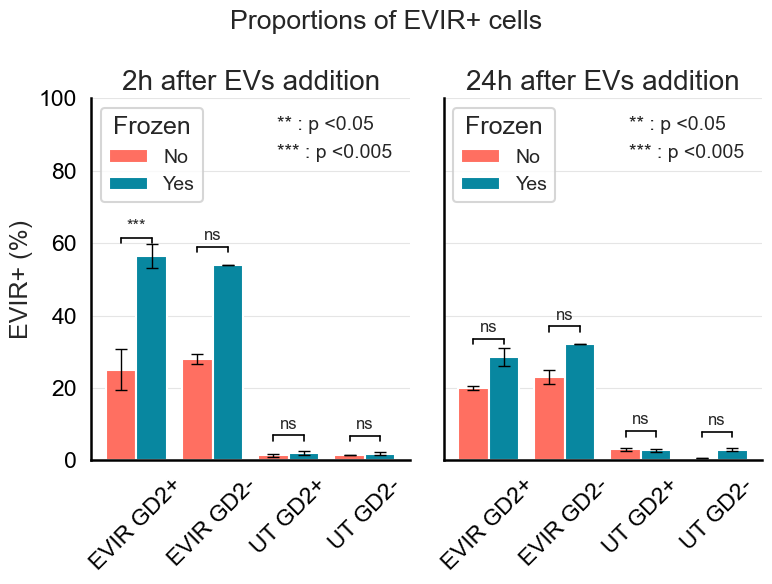

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

plot_panel_pvalue(df_2h,  ax[0], "2h", "EVIR+")
plot_panel_pvalue(df_24h, ax[1], "24h", "EVIR+")

plt.suptitle("Proportions of EVIR+ cells")
plt.tight_layout()
plt.savefig("Figures/assessing_function/proportionEVIR");